# Encoder walkthrough: probing & steering BERT

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvkevi/steerkit/blob/main/examples/case_studies/encoder_walkthrough.ipynb)

The decoder walkthroughs (`formality_walkthrough.ipynb`, `refusal_walkthrough.ipynb`) probe and steer Qwen — autoregressive, last-token, generated tokens. Encoders are different on three of those axes:

* **Bidirectional**: every token sees every other token, so the natural pooled summary is **mean over real positions**, not last-token.
* **No `.generate()`**: HookedEncoder doesn't autoregressively decode. Steering happens in a **single forward pass**, and we read the model's behavior off the masked-LM head.
* **No α calibration**: `calibrate_alpha` runs short generations to compare perplexities; with no generate path we set α directly from the projection gap of the contrast pairs and tune by inspection.

Concept: **sentiment** (positive vs. negative review). Model: **bert-base-uncased**. The visual payoff is `Probe.predict_at_mask(...)` — top-K vocabulary predictions at `[MASK]` tokens, before vs. after steering.

## Phase 0 — environment

On Colab the cell below clones the repo to `/content/steerkit` and pip-installs from there so the bundled `examples/data/` paths resolve. Locally it just resolves `REPO_ROOT` to the repo root.

In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    REPO_ROOT = Path("/content/steerkit")
    if not REPO_ROOT.exists():
        os.system(f"git clone -q https://github.com/arvkevi/steerkit {REPO_ROOT}")
    os.system(f"pip install -q {REPO_ROOT}")
else:
    cwd = Path.cwd()
    REPO_ROOT = cwd
    while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "pyproject.toml").exists():
        REPO_ROOT = REPO_ROOT.parent

os.environ.setdefault("TRANSFORMERLENS_ALLOW_MPS", "1")  # harmless on CUDA / CPU

'1'

## Phase 1 — sentiment contrast pairs

`examples/data/sentiment.jsonl` ships with 60 teacher-generated pairs: each prompt is an opinion-inviting question ("Tell me about the movie...", "How was the restaurant..."); `positive_response` is enthusiastic and glowing, `negative_response` is harsh and disappointed.

Same contrast-pair recipe as the decoder concepts — only the surface form (review text rather than refusal/formality) changes.

In [2]:
from steerkit import load_pairs_jsonl

pairs = load_pairs_jsonl(REPO_ROOT / "examples" / "data" / "sentiment.jsonl")
print(f"loaded {len(pairs)} contrast pairs")
print()
p = pairs[0]
print(f"prompt:               {p.prompt}")
print(f"positive (glowing):   {p.positive_response[:140]}...")
print(f"negative (harsh):     {p.negative_response[:140]}...")

/Users/kevin/projects/mech-interp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded 60 contrast pairs

prompt:               Tell me about the movie you watched last weekend.
positive (glowing):   I absolutely loved the movie I watched last weekend—it was incredible! The storytelling was fantastic, the cinematography was stunning, and ...
negative (harsh):     The movie I watched last weekend was absolutely terrible and disappointing. The plot was boring, the acting was awful, and I found myself ha...


## Phase 2 — load the encoder

`steerkit.load` auto-detects encoder names (`bert`, `roberta`, `deberta`, `electra`, `albert`) and routes them through TransformerLens's `HookedEncoder`. The returned `ModelHandle` exposes the same `n_layers` / `d_model` / `tokenizer` / `hooked.hooks(...)` API as the decoder path — the only behavioral difference downstream is the mask-LM head and the lack of `.generate()`.

In [3]:
from steerkit import load

model = load("bert-base-uncased")
print(f"layers={model.n_layers}  d_model={model.d_model}  device={model.device}")
print(f"is_encoder: {model.is_encoder}  mask_token: {model.tokenizer.mask_token!r} (id={model.tokenizer.mask_token_id})")

If using BERT for interpretability research, keep in mind that BERT has some significant architectural differences to GPT. For example, LayerNorms are applied *after* the attention and MLP components, meaning that the last LayerNorm in a block cannot be folded.
Loading weights: 100%|██████████| 206/206 [00:00<00:00, 7508.64it/s]


Moving model to device:  mps
Loaded pretrained model bert-base-uncased into HookedEncoder
layers=12  d_model=768  device=mps
is_encoder: True  mask_token: '[MASK]' (id=103)


## Phase 3 — extract activations with mean pooling

The decoder default — `pooling="last"` — picks the residual at the final real position. That's the right choice for autoregressive models because the last position is what conditions the next-token distribution. BERT is bidirectional: every position sees the whole sentence, so a sentence-level summary should average them. `pooling="mean"` averages residuals across all non-pad positions.

The cache key includes the pooling mode (the cache signature gets a `__mean` suffix), so changing pooling won't collide with a stale cached file from a different strategy.

In [4]:
from steerkit import extract_activations

activations = extract_activations(
    pairs, model,
    hook_site="resid_post",
    include_boundaries=False,
    pooling="mean",
    cache_dir=REPO_ROOT / "cache",
)
first_layer = next(iter(activations))
print(f"layers covered: {min(activations)}..{max(activations)}")
print(f"shape per layer: {tuple(activations[first_layer].shape)}  (n_pairs, {{pos,neg}}, d_model)")

layers covered: 0..11
shape per layer: (60, 2, 768)  (n_pairs, {pos,neg}, d_model)


## Phase 4 — fit probes per layer

Same three families as the decoder workflow — logistic regression, difference-of-means, mass-mean / shrinkage LDA — fit once per layer with held-out AUC and Cohen's d on the logistic decision-function scores. Sentiment is a high-signal concept, so AUC saturates at 1.0 across most layers; we pick by Cohen's d, which is continuous.

In [5]:
from steerkit import Probe

probes = Probe.fit_all(activations, model, hook_site="resid_post", test_fraction=0.2)
# Restrict to mid-network layers — the deepest layers specialize toward the
# MLM head's vocabulary distribution and the embedding layer fires on token
# surface ('amazing' vs 'terrible') rather than the abstract concept.
n = model.n_layers
mid_lo, mid_hi = max(2, n // 4), min(n - 2, (3 * n) // 4)
mid_probes = {layer: p for layer, p in probes.items() if mid_lo <= layer <= mid_hi}
best = Probe.best_layer(mid_probes, by="cohens_d_logistic")
print(f"best layer = {best.layer}  (depth {best.normalized_depth:.2f})")
print(f"AUC (test): {best.metrics['auc_test_logistic']:.3f}  Cohen's d: {best.metrics['cohens_d_logistic']:.2f}")

best layer = 8  (depth 0.69)
AUC (test): 1.000  Cohen's d: 13.97


## Phase 5 — visualize the layer-selection curve

The `plot_layer_selection` utility works identically for encoders. The curve typically peaks around 60-75% depth — past the syntax-y early layers and before the deep MLM-head specialization.

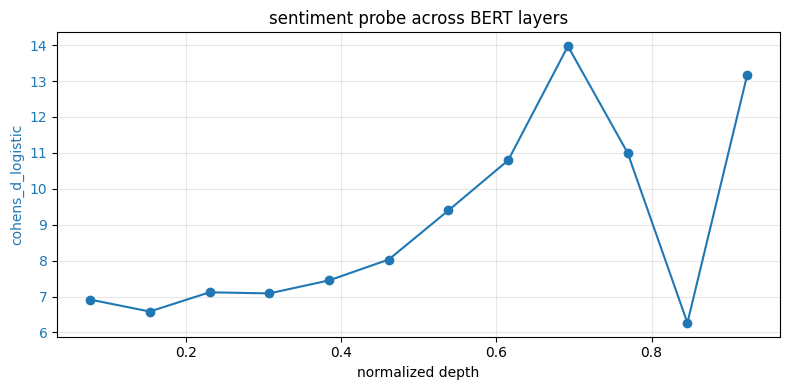

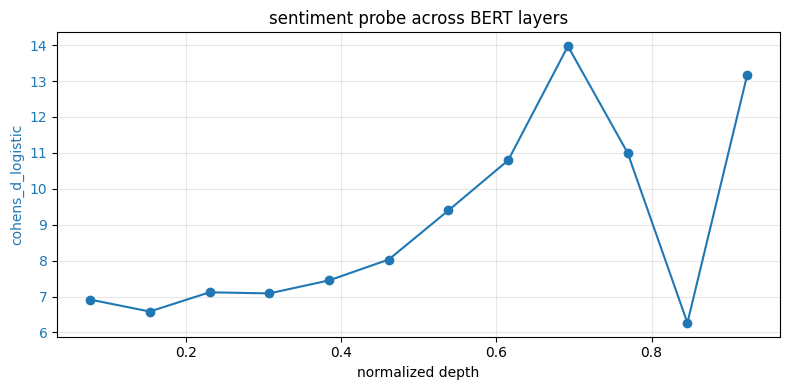

In [6]:
from steerkit import plot_layer_selection

fig = plot_layer_selection(
    probes,
    by_classifier="cohens_d_logistic",
    x_axis="normalized_depth",
    title="sentiment probe across BERT layers",
)
fig

## Phase 6 — choose α (the encoder shortcut)

`calibrate_alpha` doesn't apply: it sweeps short generations and compares perplexities, and HookedEncoder doesn't expose `.generate()`. Instead we set α from the projection-gap between the positive and negative classes on the train set — i.e. the typical magnitude with which the concept lives in the residual along this direction. That's a sensible starting point; tune by inspection on the mask-prediction outputs below.

In [7]:
import torch

direction = best.get_direction("logistic")
acts = activations[best.layer]
pos_proj = (acts[:, 0, :] @ direction).mean().item()
neg_proj = (acts[:, 1, :] @ direction).mean().item()
auto_alpha = float(abs(pos_proj - neg_proj))
best.auto_alpha = auto_alpha
print(f"pos class mean projection: {pos_proj:+.3f}")
print(f"neg class mean projection: {neg_proj:+.3f}")
print(f"auto_alpha (gap):          {auto_alpha:.3f}")

pos class mean projection: +2.949
neg class mean projection: -2.940
auto_alpha (gap):          5.889


## Phase 7 — save and reload

The `.probe.safetensors` artifact is architecture-agnostic — it carries `model_id="bert-base-uncased"` and the encoder's hook name. Reloading on a fresh `bert-base-uncased` handle produces exactly the same steering behavior.

In [8]:
best.save(REPO_ROOT / "runs" / "sentiment_bert.probe.safetensors")
reloaded = Probe.load(REPO_ROOT / "runs" / "sentiment_bert.probe.safetensors")
print(f"reloaded probe trained on {reloaded.model_id}")
print(f"  layer: {reloaded.layer}  hook: {reloaded.hook_name}")
print(f"  auto_alpha: {reloaded.auto_alpha:.3f}")

reloaded probe trained on bert-base-uncased
  layer: 8  hook: blocks.8.hook_resid_post
  auto_alpha: 5.889


## Phase 8 — steer via the masked-LM head

`probe.predict_at_mask(model, text)` is the encoder analog of `probe.steer(...)`. It runs **one forward pass** with the steering hook installed, then reads the top-K vocabulary predictions at every `[MASK]` position. Pass `alpha=0.0` for the unsteered baseline, a positive α to push toward the positive class ("glowing"), or a negative α to push toward the negative ("harsh").

In [24]:
SENTENCES = [
    "I think this movie is [MASK].",
    "The restaurant was [MASK].",
    "The hotel breakfast was absolutely [MASK].",
]

alpha = best.auto_alpha * 3  # scale up for more dramatic steering; the optimal scale may differ per model and task
for text in SENTENCES:
    print(f"== {text} ==")
    for label, alpha in [("unsteered (α=0)", 0.0), (f"positive (α=+{alpha:.1f})", +alpha), (f"negative (α=−{alpha:.1f})", -alpha)]:
        out = best.predict_at_mask(model, text, top_k=6, alpha=alpha)
        pos = next(iter(out))
        preds = ", ".join(f"{tok}({p:.2f})" for tok, p in out[pos])
        print(f"  {label:24s}  {preds}")
    print()

== I think this movie is [MASK]. ==
  unsteered (α=0)           great(0.13), amazing(0.07), good(0.06), awesome(0.05), perfect(0.03), fantastic(0.03)
  positive (α=+17.7)        wonderful(0.10), amazing(0.08), magical(0.07), incredible(0.07), great(0.07), huge(0.05)
  negative (α=−17.7)        funny(0.15), bad(0.08), worse(0.06), sick(0.05), gross(0.03), tired(0.02)

== The restaurant was [MASK]. ==
  unsteered (α=0)           packed(0.22), empty(0.11), quiet(0.09), deserted(0.04), crowded(0.04), beautiful(0.02)
  positive (α=+-17.7)       empty(0.59), quiet(0.08), crowded(0.07), packed(0.06), dark(0.04), deserted(0.04)
  negative (α=−-17.7)       amazing(0.15), wonderful(0.08), beautiful(0.06), here(0.05), huge(0.05), great(0.04)

== The hotel breakfast was absolutely [MASK]. ==
  unsteered (α=0)           delicious(0.26), wonderful(0.13), amazing(0.11), fabulous(0.08), fantastic(0.06), perfect(0.04)
  positive (α=+17.7)        wonderful(0.29), amazing(0.10), incredible(0.08), awesome

### Side-by-side: how steering reshapes the mask distribution

For a single sentence, plotting the top-K bars side-by-side at α=0 / +α / −α makes the shift obvious. The unsteered distribution is the base model's prior; the steered distributions tilt the residual along the sentiment direction at one mid-network layer, and the MLM head reads off a different ranking.

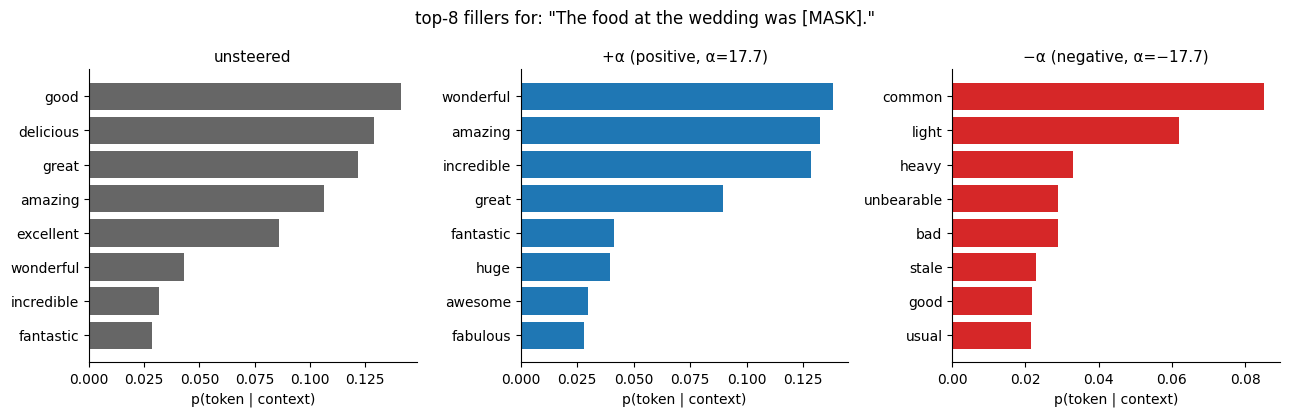

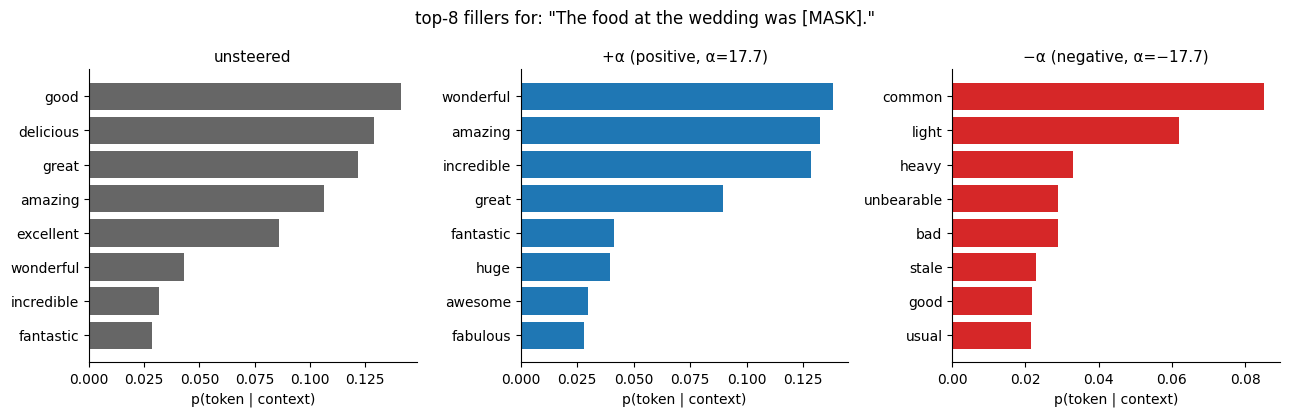

In [25]:
import matplotlib.pyplot as plt

text = "The food at the wedding was [MASK]."
alpha = best.auto_alpha * 3  # scale up for more dramatic steering; the optimal scale may differ per model and task

panels = [("unsteered", 0.0), (f"+α (positive, α={alpha:.1f})", +alpha), (f"−α (negative, α=−{alpha:.1f})", -alpha)]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=False)
for ax, (label, alpha) in zip(axes, panels):
    out = best.predict_at_mask(model, text, top_k=8, alpha=alpha)
    pos = next(iter(out))
    tokens, probs = zip(*out[pos])
    color = {"unsteered": "#666666"}.get(label.split()[0], "#1f77b4" if alpha > 0 else "#d62728")
    ax.barh(range(len(tokens)), probs, color=color)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens)
    ax.invert_yaxis()
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("p(token | context)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.suptitle(f'top-8 fillers for: "{text}"', fontsize=12)
fig.tight_layout()
fig

### The other operations work too

Same four ops as the decoder path. `predict_at_mask` accepts `op="projection"` (ablate the sentiment component), `op="clamp"` with a `target` (force projection to a fixed value), or `op="multiplicative"` with a `gamma` (scale the existing component). Useful for *removing* a learned bias rather than amplifying one.

In [26]:
text = "The food at the wedding was [MASK]."
ops = [
    ("baseline (α=0)",      {"alpha": 0.0}),
    ("ablate (projection)", {"op": "projection"}),
    ("clamp target=+5",     {"op": "clamp", "target": +5.0}),
    ("clamp target=−5",     {"op": "clamp", "target": -5.0}),
    ("amplify γ=3",         {"op": "multiplicative", "gamma": 3.0}),
]
print(f"== {text} ==")
for label, kwargs in ops:
    out = best.predict_at_mask(model, text, top_k=5, **kwargs)
    pos = next(iter(out))
    preds = ", ".join(f"{tok}({p:.2f})" for tok, p in out[pos])
    print(f"  {label:22s}  {preds}")

== The food at the wedding was [MASK]. ==
  baseline (α=0)          good(0.14), delicious(0.13), great(0.12), amazing(0.11), excellent(0.09)
  ablate (projection)     amazing(0.15), great(0.15), delicious(0.12), good(0.10), excellent(0.07)
  clamp target=+5         amazing(0.27), great(0.14), incredible(0.10), fantastic(0.07), wonderful(0.07)
  clamp target=−5         good(0.16), delicious(0.08), excellent(0.06), great(0.05), awful(0.03)
  amplify γ=3             good(0.15), delicious(0.09), great(0.06), excellent(0.06), amazing(0.03)


## What's next

* **More encoder concepts**: any contrast-pair concept that has a clear positive/negative axis works — toxicity, formality, certainty, professional-vs-casual.
* **Compose with a decoder probe**: encoder probes don't help on a decoder, but the contrast-pair JSONL is portable. Fit the same dataset on Qwen and on BERT to compare directions across architectures.
* **Linting**: the same `steerkit lint-pairs` checks apply (length parity, lexical leakage, etc.).
* **Decoder walkthrough**: see `examples/case_studies/formality_walkthrough.ipynb` for the autoregressive equivalent of this notebook.